In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


In [3]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [4]:
# Dictionary of H5 files with labels for tracking
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}

# Create a dictionary to store results
resp_data = {}

# Loop through files and apply the function
for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("All available signals loaded.")

Processing RI1_3_6...
Processing RI1_4_7...
Processing RI1_2_3...
Processing RI1_4_8...
Processing RI1_1_1...
Processing RI1_1_2...
Processing RI1_2_4...
Processing RI1_3_5...
Processing RI2_3_6...
Processing RI2_4_7...
Processing RI2_2_3...
Processing RI2_4_8...
Processing RI2_1_1...
Processing RI2_1_2...
Processing RI2_2_4...
Processing RI2_3_5...
All available signals loaded.


In [5]:
import pandas as pd

# Define file paths again if needed
ri1_path = r"E:\Aim1\AIM1\Day1_new\Sleap_dis_far_clos\RI1FARCLOSEDATA.xlsx"
ri2_path = r"E:\Aim1\AIM1\Day1_new\Sleap_dis_far_clos\RI2FARCLOSEDATA.xlsx"

# ✅ Load all sheets into dictionaries
ri1_sheets = pd.read_excel(ri1_path, sheet_name=None)
ri2_sheets = pd.read_excel(ri2_path, sheet_name=None)


In [6]:
sleap_data = {}

# Add RI1 sheets with 'RI1_' prefix
for key, df in ri1_sheets.items():
    sleap_data[f"RI1_{key}"] = df

# Add RI2 sheets with 'RI2_' prefix
for key, df in ri2_sheets.items():
    sleap_data[f"RI2_{key}"] = df

print(f"✅ Reloaded sleap_data with {len(sleap_data)} keys")
print("Example keys:", list(sleap_data.keys())[:5])


✅ Reloaded sleap_data with 18 keys
Example keys: ['RI1_RI1_s1_1_p5_2_nRB6_20250622_143', 'RI1_RI1_s1_2_p5_1_nRB6_20250622_170', 'RI1_RI1_s2_3_p5_3_nRB3_20250622_104', 'RI1_RI1_s2_4_p5_4_nRB3_20250622_123', 'RI1_RI1_s3_5_p5_4_nRB3_20250621_105']


In [7]:
# # Load all sheets with corrected keys
# sleap_data = {}

# for key, df in ri1_sheets.items():
#     new_key = key
#     if key.startswith('RI1_'):
#         new_key = key[len('RI1_'):]  # strip leading 'RI1_'
#     sleap_data[new_key] = df

# for key, df in ri2_sheets.items():
#     new_key = key
#     if key.startswith('RI2_'):
#         new_key = key[len('RI2_'):]  # strip leading 'RI2_'
#     sleap_data[new_key] = df
# print(f"✅ Loaded sleap_data with {len(sleap_data)} keys")
# print("Example keys:", list(sleap_data.keys())[:5])


In [8]:
# # Reload sleap_data with cleaned keys
# sleap_data = {}

# # Clean RI1 keys
# for sheet_name, df in ri1_sheets.items():
#     cleaned_key = sheet_name  # no extra prefix
#     sleap_data[cleaned_key] = df

# # Clean RI2 keys
# for sheet_name, df in ri2_sheets.items():
#     cleaned_key = sheet_name.replace("labels.vFULL.", "")  # if needed
#     sleap_data[cleaned_key] = df

# print(f"✅ Reloaded sleap_data with {len(sleap_data)} cleaned keys")
# print("Example keys:", list(sleap_data.keys())[:5])


In [9]:
default_fps = 30
fps_corrections = {
    "RI1_1_1": 15,
    "RI1_2_3": 15,
    "RI1_3_6": 29,
    "RI2_1_1": 15,
    "RI2_2_4": 15
}


In [10]:
matched_sleap_keys = {}

for resp_key in resp_data.keys():
    group = resp_key.split("_")[0]             # RI1 or RI2
    subj_id = "_".join(resp_key.split("_")[1:])  # e.g., '3_6'

    # Only match SLEAP keys that match the correct group
    candidates = [
        k for k in sleap_data.keys()
        if k.startswith(group) and subj_id.replace("_", "") in k.replace("_", "")
    ]

    if candidates:
        matched_sleap_keys[resp_key] = candidates[0]
        print(f"✅ Matched {resp_key} to {candidates[0]}")
    else:
        print(f"⚠️ No match for {resp_key}")


✅ Matched RI1_3_6 to RI1_RI1_s3_6_p5_3_nRB3_20250621_125
✅ Matched RI1_4_7 to RI1_RI1_s4_7_p5_2_nRB3_20250621_150
✅ Matched RI1_2_3 to RI1_RI1_s2_3_p5_3_nRB3_20250622_104
✅ Matched RI1_4_8 to RI1_RI1_s4_8_p5_1_nRB3_20250621_165
✅ Matched RI1_1_1 to RI1_RI1_s1_1_p5_2_nRB6_20250622_143
✅ Matched RI1_1_2 to RI1_RI1_s1_2_p5_1_nRB6_20250622_170
✅ Matched RI1_2_4 to RI1_RI1_s2_4_p5_4_nRB3_20250622_123
✅ Matched RI1_3_5 to RI1_RI1_s3_5_p5_4_nRB3_20250621_105
✅ Matched RI2_3_6 to RI2_labels.vFULL.005_RI2_s3_6_p_5_3
✅ Matched RI2_4_7 to RI2_labels.vFULL.006_RI2_s4_7_p5_2_
✅ Matched RI2_2_3 to RI2_labels.vFULL.008_RI2_s2_3_p5_3_
✅ Matched RI2_4_8 to RI2_labels.vFULL.007_RI2_s4_8_p5_1_
✅ Matched RI2_1_1 to RI2_labels.vFULL.001_RI2_s1_1_p5_2_
✅ Matched RI2_1_2 to RI2_labels.vFULL.002_RI2_s1_2_p5_1_
✅ Matched RI2_2_4 to RI2_labels.vFULL.003_RI2_s2_4_p5_4_
✅ Matched RI2_3_5 to RI2_labels.vFULL.004_RI2_s3_5_p5_4_


In [11]:
all_labeled_respiration = []

for label, match in matched_sleap_keys.items():
    try:
        # Get respiration and SLEAP data
        resp_entry = resp_data[label]
        sleap_entry = sleap_data[match]

        # Determine FPS
        fps = fps_corrections.get(label, default_fps)

        # SLEAP frame-to-time
        sleap_df = sleap_entry.copy()
        sleap_df['Frame'] = pd.to_numeric(sleap_df['frame'], errors='coerce')
        sleap_df['Time'] = sleap_df['Frame'] / fps

        # Proximity via mode (fallback if NaNs)
        proximity_cols = [col for col in sleap_df.columns if 'mouse' in col or 'nose' in col or 'middle' in col]
        try:
            sleap_df['Proximity'] = sleap_df[proximity_cols].mode(axis=1).iloc[:, 0]
        except IndexError:
            sleap_df['Proximity'] = sleap_df[proximity_cols].bfill(axis=1).iloc[:, 0]

        # Respiration signal to DataFrame
        resp_df = pd.DataFrame({
            "Time": resp_entry["time"],
            "RespirationSignal": resp_entry["signal"]
        })

        # Align respiration and SLEAP by time
        aligned_df = pd.merge_asof(
            resp_df.sort_values("Time"),
            sleap_df[['Time', 'Proximity']].dropna().sort_values("Time"),
            on="Time",
            direction="nearest",
            tolerance=1 / 30  # max FPS
        )

        aligned_df['Subject'] = label
        aligned_df['Group'] = 'RI1' if 'RI1' in label else 'RI2'

        all_labeled_respiration.append(aligned_df)
        print(f"✅ {label} aligned successfully.")

    except Exception as e:
        print(f"❌ Error processing {label}: {e}")

# Combine everything
respiration_by_proximity_df = pd.concat(all_labeled_respiration, ignore_index=True)


✅ RI1_3_6 aligned successfully.
✅ RI1_4_7 aligned successfully.
✅ RI1_2_3 aligned successfully.
✅ RI1_4_8 aligned successfully.
✅ RI1_1_1 aligned successfully.
✅ RI1_1_2 aligned successfully.
✅ RI1_2_4 aligned successfully.
✅ RI1_3_5 aligned successfully.
✅ RI2_3_6 aligned successfully.
✅ RI2_4_7 aligned successfully.
✅ RI2_2_3 aligned successfully.
✅ RI2_4_8 aligned successfully.
✅ RI2_1_1 aligned successfully.
✅ RI2_1_2 aligned successfully.
✅ RI2_2_4 aligned successfully.
✅ RI2_3_5 aligned successfully.


In [ ]:
respiration_by_proximity_df

In [ ]:
from scipy.signal import find_peaks
import numpy as np

def compute_respiration_rate(df, sampling_rate=100, min_peak_interval=0.0833):
    """
    Compute instantaneous respiration rate based on peak detection.
    
    Parameters:
    - sampling_rate: Hz
    - min_peak_interval: in seconds (e.g., 0.0833s for 12Hz)
    
    Returns:
    - df with new 'RespirationRate' column
    """
    signal = df['RespirationSignal'].values
    time = df['Time'].values

    # Convert time interval to minimum distance in samples
    min_distance_samples = int(min_peak_interval * sampling_rate)

    # Find peaks
    peaks, _ = find_peaks(signal, distance=min_distance_samples)

    # Compute respiration rate
    peak_times = time[peaks]
    rr_inst = np.diff(peak_times)
    rate_hz = 1 / rr_inst

    # Spread the rate values across intervals
    rate_full = np.full_like(time, np.nan, dtype=np.float64)
    for i in range(1, len(peaks)):
        start, end = peaks[i - 1], peaks[i]
        rate_full[start:end] = rate_hz[i - 1]

    df['RespirationRate'] = rate_full
    return df


In [ ]:
respiration_by_proximity_df = (
    respiration_by_proximity_df
    .groupby("Subject", group_keys=False)
    .apply(lambda df: compute_respiration_rate(df.reset_index(drop=True)))
)



C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\2123098971.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: compute_respiration_rate(df.reset_index(drop=True)))


In [ ]:
respiration_by_proximity_df

In [ ]:
# Assuming your dataframe is 'df' and the subject label is in 'Subject' column:
df['Group'] = df['Subject'].apply(lambda x: 'RI1' if x.startswith('RI1') else 'RI2')


In [ ]:
df_ri1 = df[df['Group'] == 'RI1'].copy()
df_ri2 = df[df['Group'] == 'RI2'].copy()


In [ ]:
from scipy.stats import ttest_ind

for group_df, group_name in [(df_ri1, "RI1"), (df_ri2, "RI2")]:
    close_resp = group_df.loc[group_df['Proximity'] == 'Close', 'RespirationRate']
    far_resp = group_df.loc[group_df['Proximity'] == 'Far', 'RespirationRate']

    stat, p = ttest_ind(close_resp, far_resp, nan_policy='omit')
    print(f"T-test for {group_name}: t = {stat:.3f}, p = {p:.3f}")


T-test for RI1: t = 37.840, p = 0.000
T-test for RI2: t = 87.408, p = 0.000


In [ ]:
print("RI1 group means:")
print(df_ri1.groupby('Proximity')['RespirationRate'].mean())

print("RI2 group means:")
print(df_ri2.groupby('Proximity')['RespirationRate'].mean())


RI1 group means:
Proximity
Close    8.115563
Far      7.804572
Name: RespirationRate, dtype: float64
RI2 group means:
Proximity
Close    6.680665
Far      6.124646
Name: RespirationRate, dtype: float64


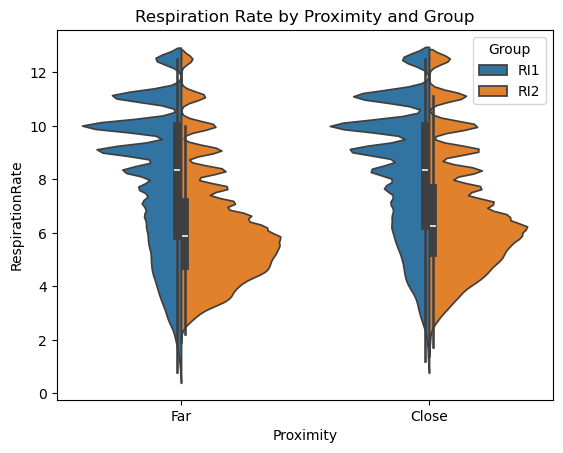

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='Proximity', y='RespirationRate', hue='Group', data=df, split=True)
plt.title('Respiration Rate by Proximity and Group')
plt.show()


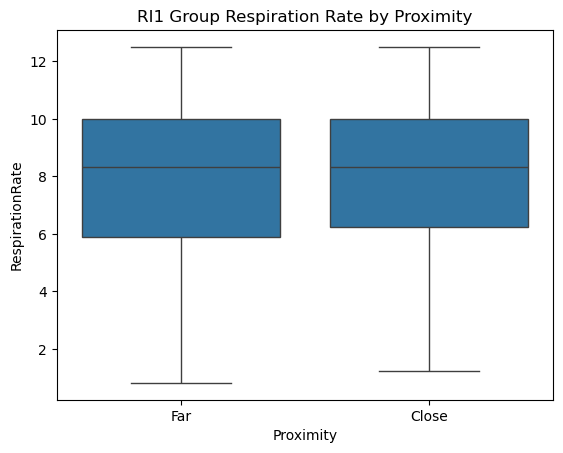

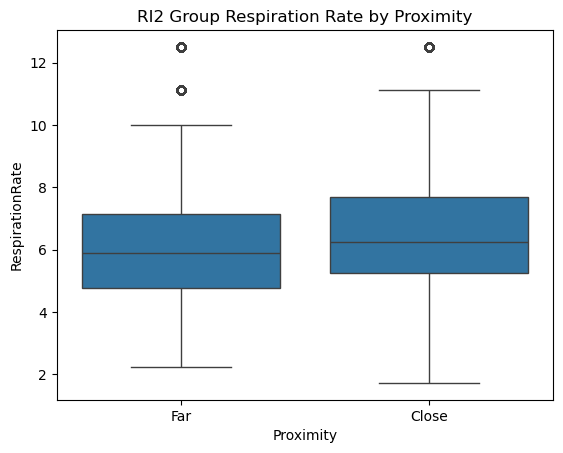

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Proximity', y='RespirationRate', data=df_ri1)
plt.title('RI1 Group Respiration Rate by Proximity')
plt.show()

sns.boxplot(x='Proximity', y='RespirationRate', data=df_ri2)
plt.title('RI2 Group Respiration Rate by Proximity')
plt.show()


In [ ]:
# Add a column to track which condition each row is from
df_ri1['Condition'] = 'RI1'  # Positive valence
df_ri2['Condition'] = 'RI2'  # Negative valence

# Combine them into one DataFrame
all_data = pd.concat([df_ri1, df_ri2], ignore_index=True)


In [ ]:
import pandas as pd
from scipy.stats import ttest_rel
import numpy as np

# Step 1: Average respiration per Subject per Proximity condition
subject_means = all_data.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack()

# Drop any subjects missing a condition
subject_means = subject_means.dropna()

# Step 2: Paired t-test on subject means
t_stat, p_val = ttest_rel(subject_means['Close'], subject_means['Far'])

# Step 3: Calculate effect size (Cohen's d for paired samples)
diff = subject_means['Close'] - subject_means['Far']
cohens_d = diff.mean() / diff.std(ddof=1)

# Step 4: Print results
print("Paired t-test on subject-level means:")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")


Paired t-test on subject-level means:
t = 6.486, p = 0.0000
Cohen's d = 1.621


In [ ]:
from scipy.stats import ttest_rel
import numpy as np

for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Get subject-level means per proximity
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack()
    subject_means = subject_means.dropna()
    
    # Paired t-test
    t_stat, p_val = ttest_rel(subject_means['Close'], subject_means['Far'])
    
    # Effect size
    diff = subject_means['Close'] - subject_means['Far']
    cohens_d = diff.mean() / diff.std(ddof=1)
    
    print(f"🔹 {condition} (Valence: {'Positive' if condition=='RI1' else 'Negative'})")
    print(f"    Paired t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"    Cohen’s d = {cohens_d:.3f}\n")


🔹 RI1 (Valence: Positive)
    Paired t = 3.147, p = 0.0162
    Cohen’s d = 1.113

🔹 RI2 (Valence: Negative)
    Paired t = 8.028, p = 0.0001
    Cohen’s d = 2.838



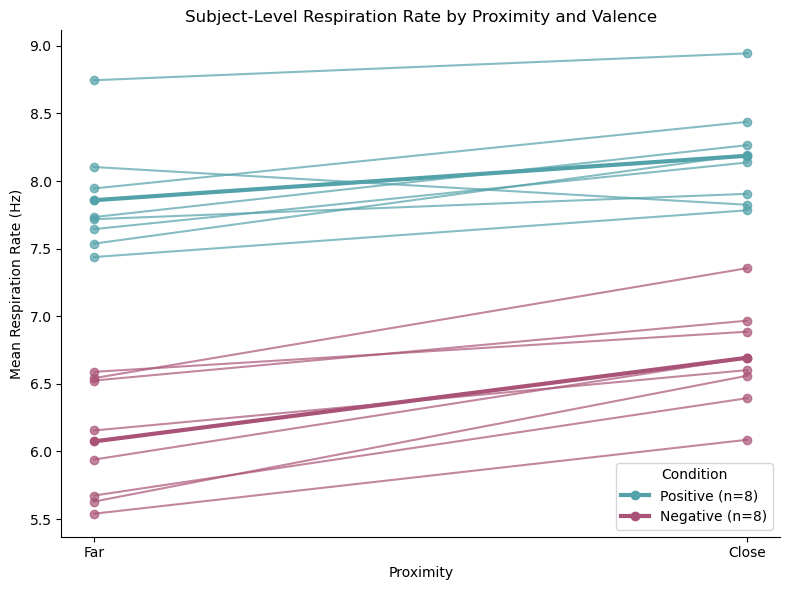

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your custom palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

fig, ax = plt.subplots(figsize=(8,6))

for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Compute subject means per proximity
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack()
    subject_means = subject_means.dropna()

    # Map condition to valence label for colors
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    
    # Plot each subject’s line (Far to Close)
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'], 
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)
    
    # Plot mean line with thicker width and label
    mean_far = subject_means['Far'].mean()
    mean_close = subject_means['Close'].mean()
    ax.plot(['Far', 'Close'], [mean_far, mean_close],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")

ax.set_xlabel('Proximity')
ax.set_ylabel('Mean Respiration Rate (Hz)')
ax.set_title('Subject-Level Respiration Rate by Proximity and Valence')
ax.legend(title='Condition')
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import wilcoxon

for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Calculate mean respiration rate per subject and proximity
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack()
    subject_means = subject_means.dropna()
    
    # Wilcoxon signed-rank test (paired)
    stat, p_val = wilcoxon(subject_means['Close'], subject_means['Far'])
    
    print(f"🔹 {condition} (Valence: {'Positive' if condition=='RI1' else 'Negative'})")
    print(f"    Wilcoxon stat = {stat:.3f}, p = {p_val:.4f}\n")


🔹 RI1 (Valence: Positive)
    Wilcoxon stat = 3.000, p = 0.0391

🔹 RI2 (Valence: Negative)
    Wilcoxon stat = 0.000, p = 0.0078



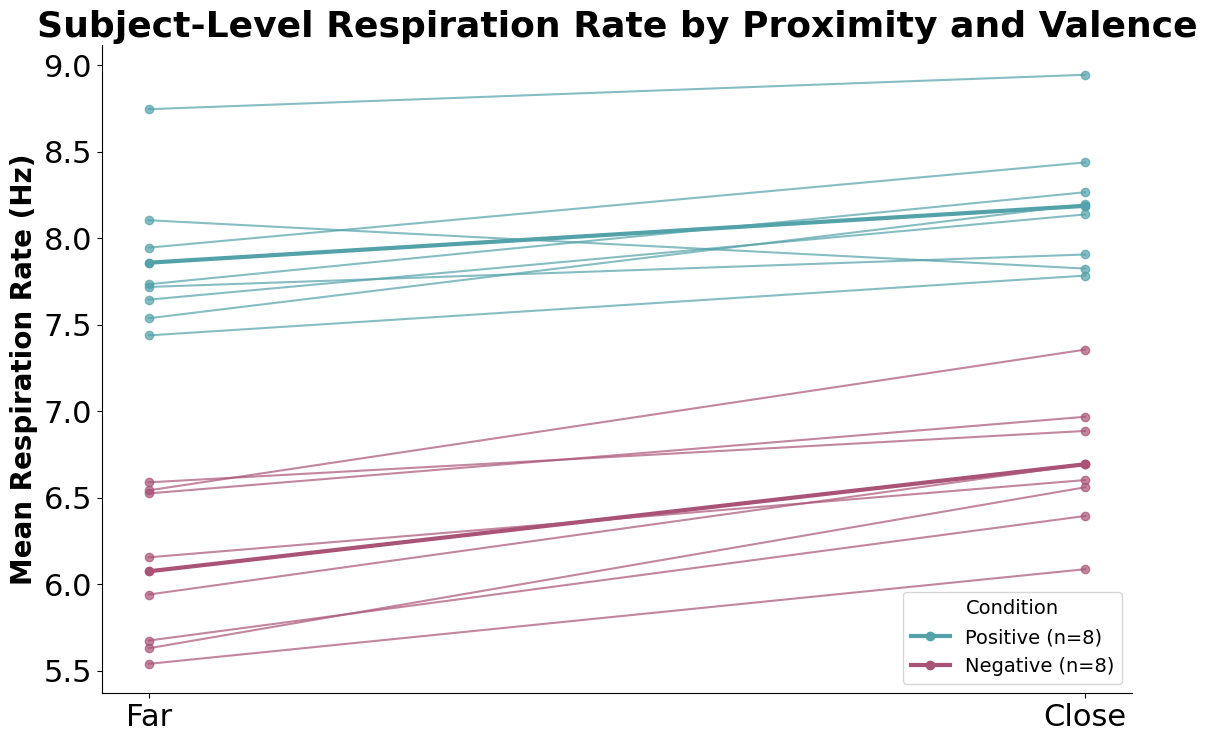

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set global font size
plt.rcParams.update({'font.size': 26})

# Custom color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Increase figure size for large font
fig, ax = plt.subplots(figsize=(12, 8))

for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Compute subject means per proximity
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack()
    subject_means = subject_means.dropna()

    # Map condition to valence label for colors
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    
    # Plot each subject’s line (Far to Close)
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'], 
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)
    
    # Plot mean line with thicker width and label
    mean_far = subject_means['Far'].mean()
    mean_close = subject_means['Close'].mean()
    ax.plot(['Far', 'Close'], [mean_far, mean_close],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")

# Bold labels with font size
ax.set_xlabel('', fontweight='bold', fontsize=20)
ax.set_ylabel('Mean Respiration Rate (Hz)', fontweight='bold', fontsize=20)
ax.set_title('Subject-Level Respiration Rate by Proximity and Valence', fontweight='bold', fontsize=26)

# Update tick label sizes
ax.tick_params(axis='both', labelsize=22)

# Legend and clean-up
ax.legend(title='Condition', fontsize=14, title_fontsize=14, )
sns.despine()
plt.tight_layout()
plt.show()


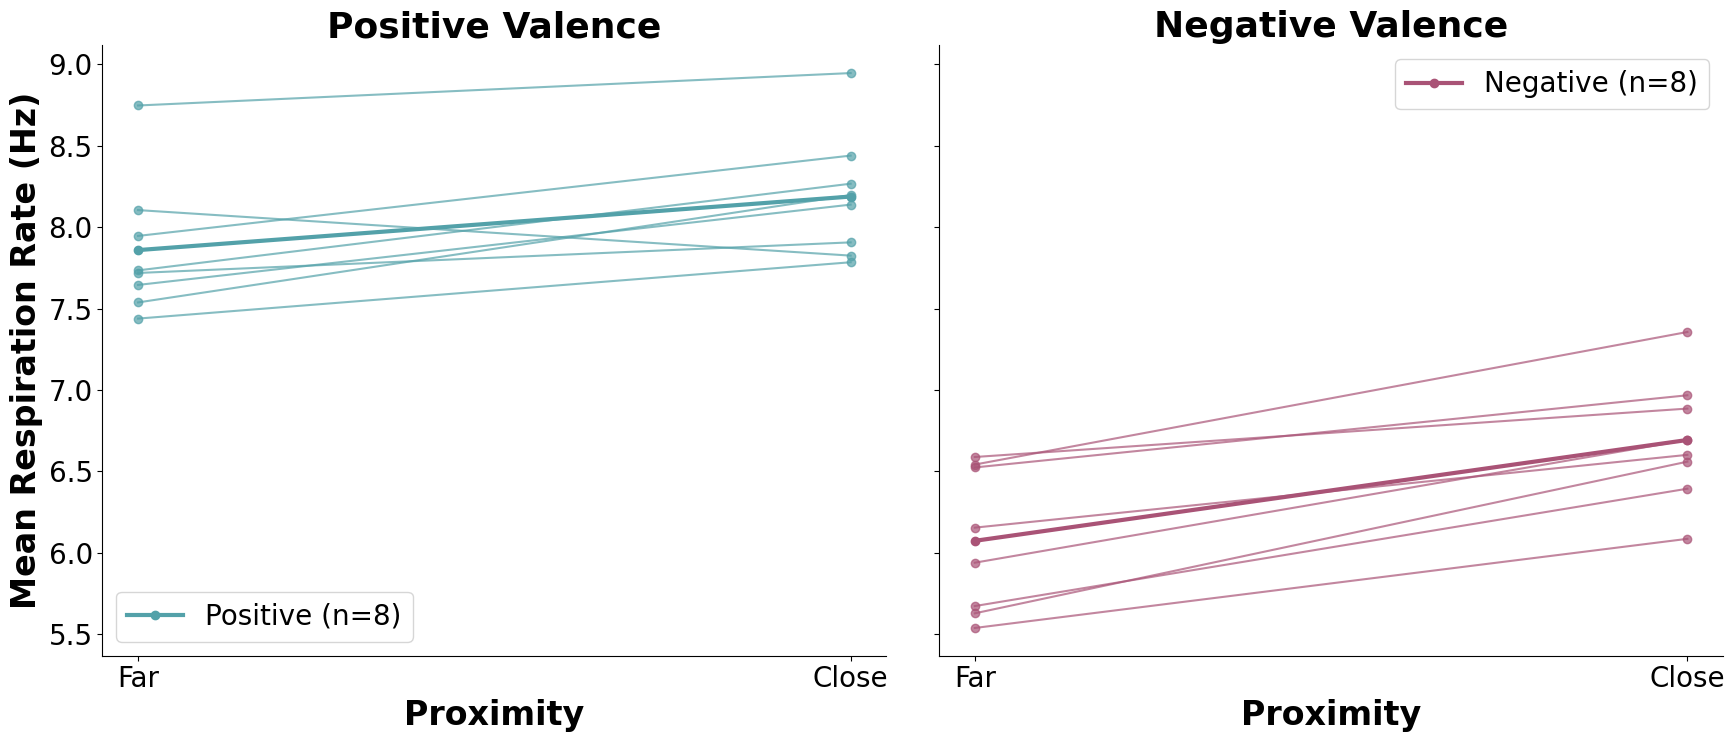

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

for i, condition in enumerate(['RI1', 'RI2']):
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Subject-level means
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()

    # Color and label
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    ax = axes[i]
    
    # Individual lines
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'], 
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)

    # Mean line
    ax.plot(['Far', 'Close'], 
            [subject_means['Far'].mean(), subject_means['Close'].mean()],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")
    
    ax.set_title(f'{valence} Valence', fontweight='bold', fontsize=26)
    ax.set_xlabel('Proximity', fontweight='bold', fontsize=24)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=20)

axes[0].set_ylabel('Mean Respiration Rate (Hz)', fontweight='bold', fontsize=24)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    
    # Subject-level means
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()
    
    # Percent change = ((Close - Far) / Far) * 100
    percent_change = ((subject_means['Close'] - subject_means['Far']) / subject_means['Far']) * 100
    
    mean_pc = percent_change.mean()
    sem_pc = percent_change.sem()
    
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    print(f"{valence} Valence (Condition: {condition})")
    print(f"  📈 Mean % increase in Respiration Rate: {mean_pc:.2f}% ± {sem_pc:.2f}%\n")


Positive Valence (Condition: RI1)
  📈 Mean % increase in Respiration Rate: 4.27% ± 1.35%

Negative Valence (Condition: RI2)
  📈 Mean % increase in Respiration Rate: 10.35% ± 1.40%



C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\954557249.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\954557249.py:71: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\954557249.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend().remove()


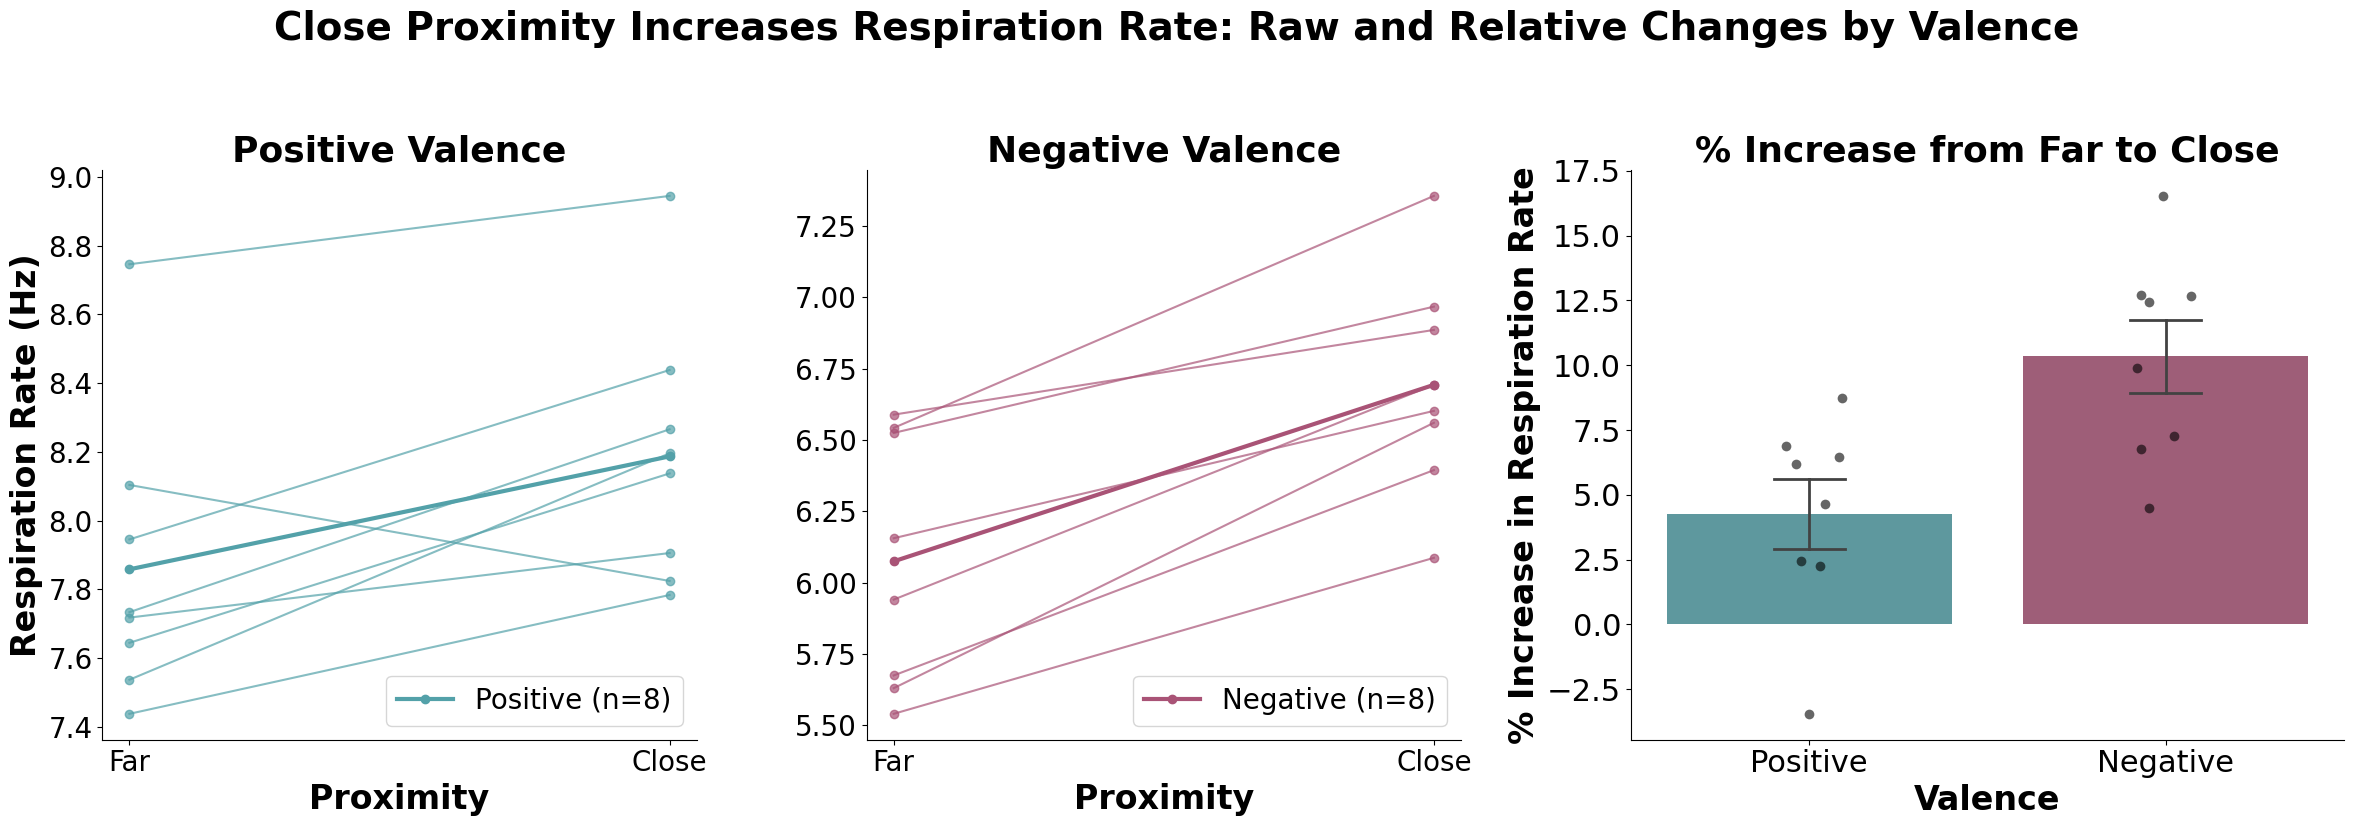

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Font settings
plt.rcParams.update({'font.size': 22})

# Color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),
    'Negative': (169/255, 83/255, 118/255)
}

# Prepare % change data
percent_changes = []

for condition in ['RI1', 'RI2']:
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    sub_df = all_data[all_data['Condition'] == condition]
    
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()
    
    for subject in subject_means.index:
        far = subject_means.loc[subject, 'Far']
        close = subject_means.loc[subject, 'Close']
        percent_change = ((close - far) / far) * 100
        percent_changes.append({
            'Subject': subject,
            'Valence': valence,
            'PercentChange': percent_change
        })

percent_df = pd.DataFrame(percent_changes)

# === PLOTTING ===
fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'width_ratios': [1, 1, 1.2]})

for i, condition in enumerate(['RI1', 'RI2']):
    sub_df = all_data[all_data['Condition'] == condition]
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()

    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    ax = axes[i]

    # Individual lines
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'],
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)

    # Group mean
    ax.plot(['Far', 'Close'],
            [subject_means['Far'].mean(), subject_means['Close'].mean()],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")

    ax.set_title(f'{valence} Valence', fontweight='bold', fontsize=26)
    ax.set_xlabel('Proximity', fontweight='bold', fontsize=24)
    ax.tick_params(axis='both', labelsize=20)
    
    # Legend positioning
    if i == 0:
        ax.legend(fontsize=20)  # default (upper right)
    else:
        ax.legend(fontsize=20, loc='lower right')

axes[0].set_ylabel('Respiration Rate (Hz)', fontweight='bold', fontsize=24)

# % Change Plot
sns.barplot(data=percent_df, x='Valence', y='PercentChange',
            palette=custom_palette, errorbar='se', capsize=0.2, errwidth=2, ax=axes[2])

sns.stripplot(data=percent_df, x='Valence', y='PercentChange',
              color='black', size=7, alpha=0.6, jitter=True, ax=axes[2])

axes[2].set_title('% Increase from Far to Close', fontweight='bold', fontsize=26)
axes[2].set_ylabel('% Increase in Respiration Rate', fontweight='bold', fontsize=24)
axes[2].set_xlabel('Valence', fontweight='bold', fontsize=24)
axes[2].tick_params(axis='both', labelsize=22)
axes[2].legend().remove()

sns.despine()

# Unified title
fig.suptitle("Close Proximity Increases Respiration Rate: Raw and Relative Changes by Valence",
             fontsize=28, fontweight='bold', y=1.05)

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # make space for suptitle
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\2235506725.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\2235506725.py:58: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\2235506725.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend().remove()


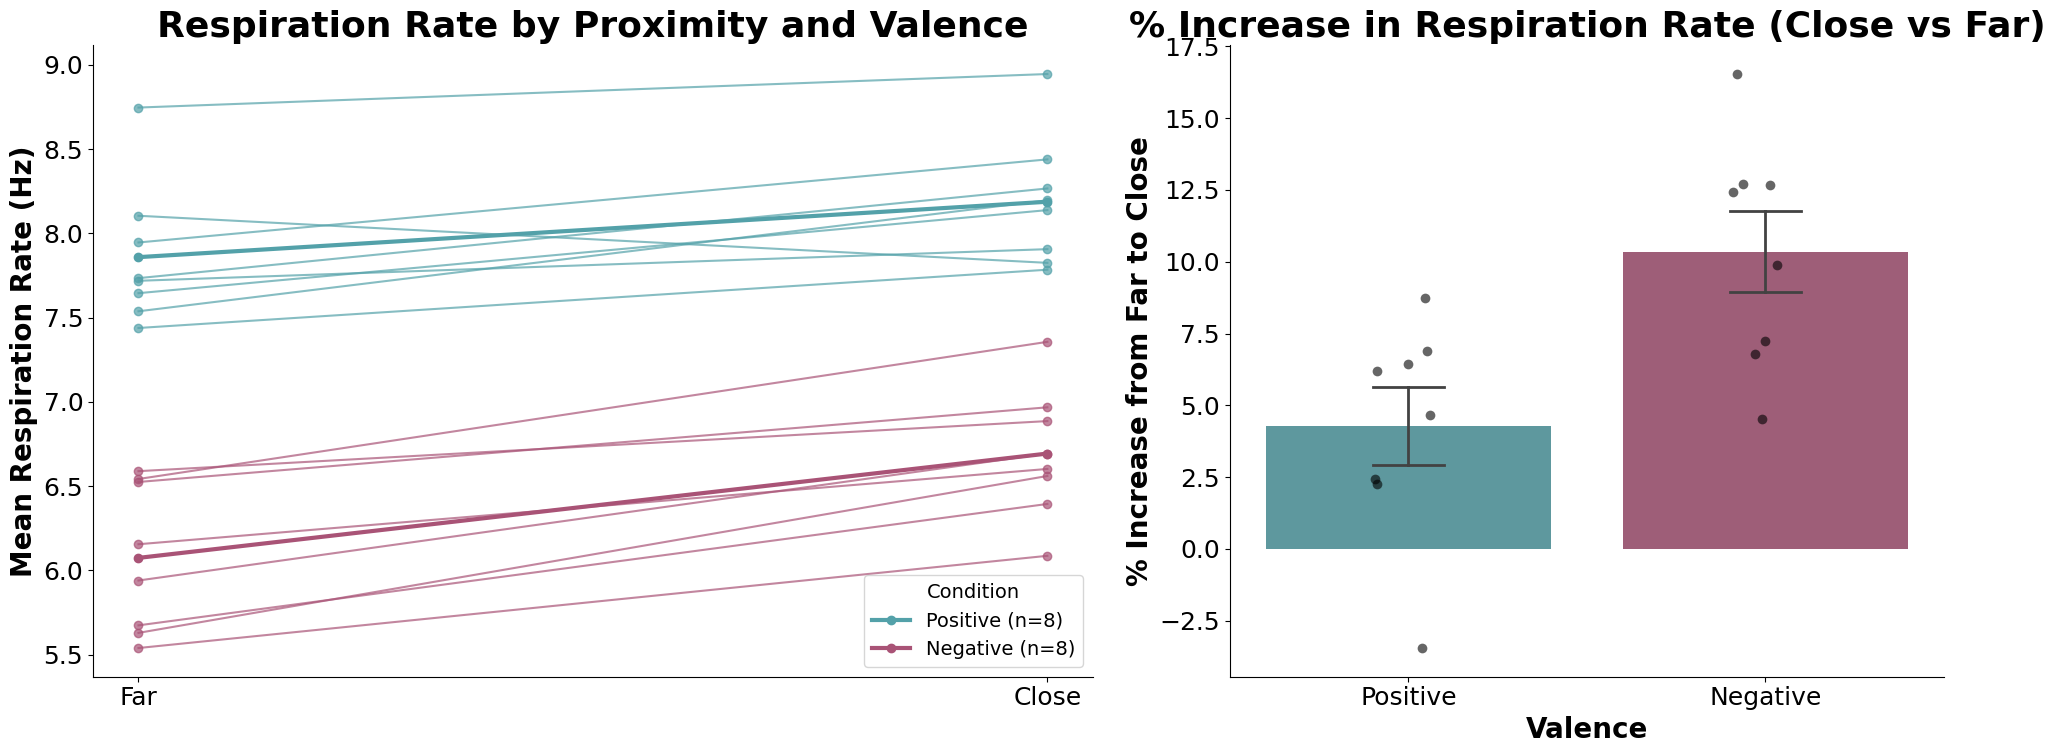

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams.update({'font.size': 22})

custom_palette = {
    'Positive': (83/255, 161/255, 169/255),
    'Negative': (169/255, 83/255, 118/255)
}

# Prepare % change data (same as your first block)
percent_changes = []
for condition in ['RI1', 'RI2']:
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    sub_df = all_data[all_data['Condition'] == condition]
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()

    for subject in subject_means.index:
        far = subject_means.loc[subject, 'Far']
        close = subject_means.loc[subject, 'Close']
        percent_change = ((close - far) / far) * 100
        percent_changes.append({'Subject': subject, 'Valence': valence, 'PercentChange': percent_change})

percent_df = pd.DataFrame(percent_changes)

# Create 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1.4, 1]})

# Left: Respiration Rate by Proximity + Valence (your second block)
ax = axes[0]
for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'], 
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)
    
    mean_far = subject_means['Far'].mean()
    mean_close = subject_means['Close'].mean()
    ax.plot(['Far', 'Close'], [mean_far, mean_close],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")

ax.set_xlabel('', fontweight='bold', fontsize=20)
ax.set_ylabel('Mean Respiration Rate (Hz)', fontweight='bold', fontsize=20)
ax.set_title('Respiration Rate by Proximity and Valence', fontweight='bold', fontsize=26)
ax.tick_params(axis='both', labelsize=18)
ax.legend(title='Condition', fontsize=14, title_fontsize=14)
sns.despine(ax=ax)

# Right: Percent change bar + stripplot (your first block)
ax2 = axes[1]
sns.barplot(data=percent_df, x='Valence', y='PercentChange',
            palette=custom_palette, errorbar='se', capsize=0.2, errwidth=2, ax=ax2)
sns.stripplot(data=percent_df, x='Valence', y='PercentChange',
              color='black', size=7, alpha=0.6, jitter=True, ax=ax2)
ax2.set_title('% Increase in Respiration Rate (Close vs Far)', fontweight='bold', fontsize=26)
ax2.set_ylabel('% Increase from Far to Close', fontweight='bold', fontsize=20)
ax2.set_xlabel('Valence', fontweight='bold', fontsize=20)
ax2.tick_params(axis='both', labelsize=18)
ax2.legend().remove()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\898501405.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\898501405.py:58: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=percent_df, x='Valence', y='PercentChange',
C:\Users\sjs93\AppData\Local\Temp\ipykernel_25740\898501405.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend().remove()


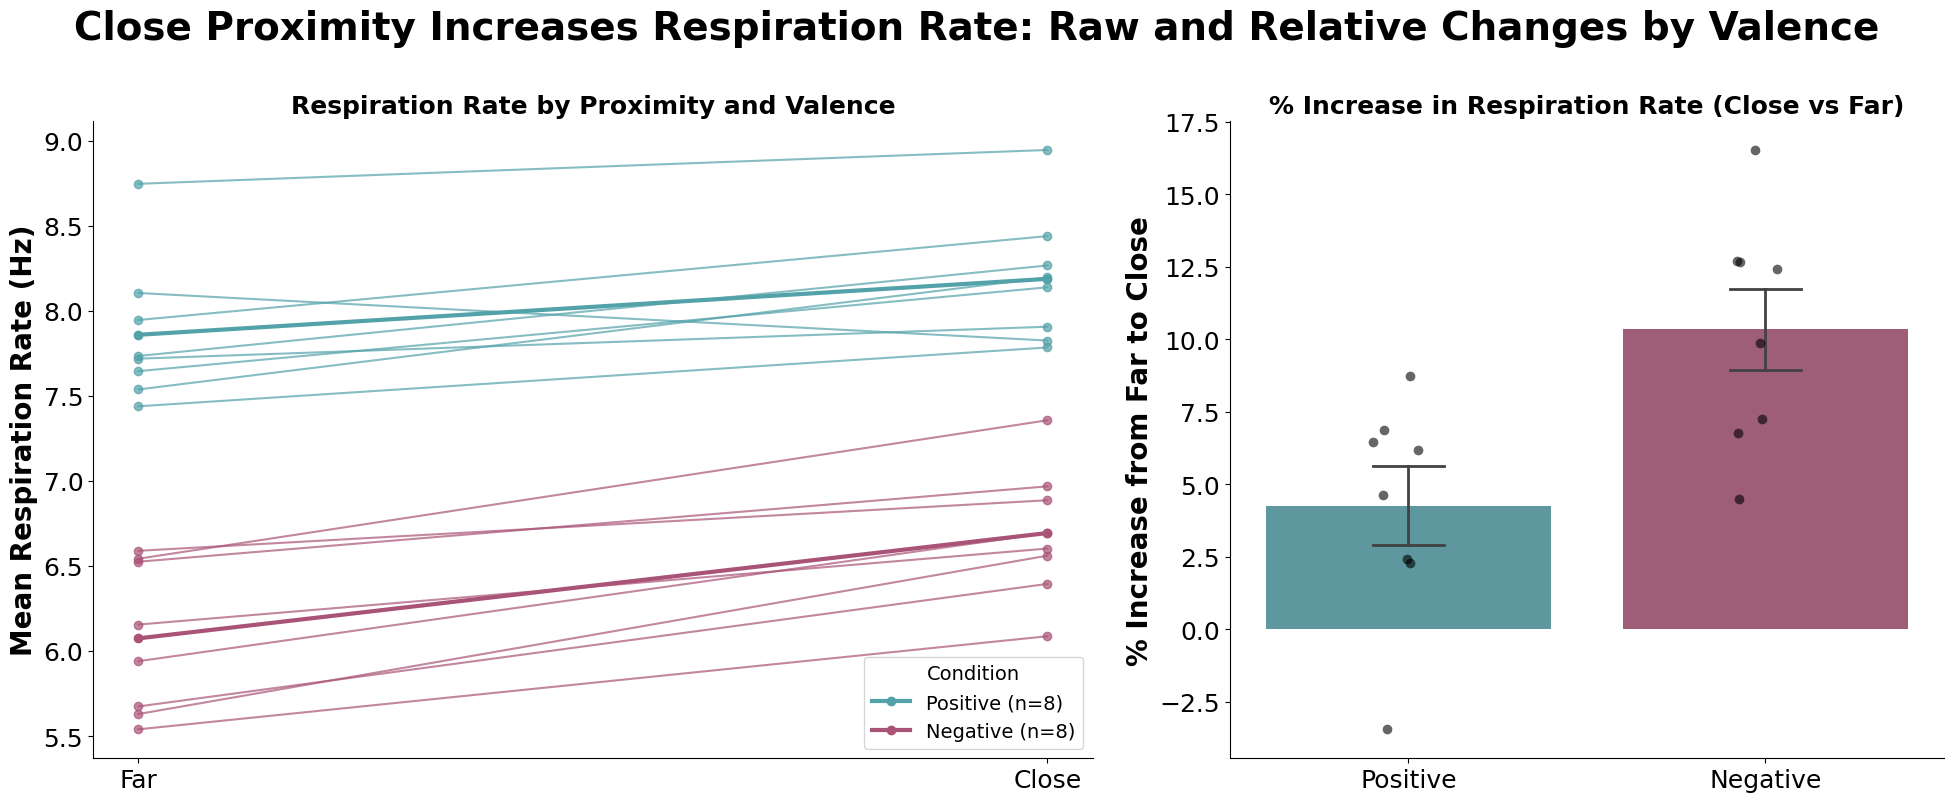

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams.update({'font.size': 22})

custom_palette = {
    'Positive': (83/255, 161/255, 169/255),
    'Negative': (169/255, 83/255, 118/255)
}

# Prepare % change data
percent_changes = []
for condition in ['RI1', 'RI2']:
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    sub_df = all_data[all_data['Condition'] == condition]
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()

    for subject in subject_means.index:
        far = subject_means.loc[subject, 'Far']
        close = subject_means.loc[subject, 'Close']
        percent_change = ((close - far) / far) * 100
        percent_changes.append({'Subject': subject, 'Valence': valence, 'PercentChange': percent_change})

percent_df = pd.DataFrame(percent_changes)

# Create 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1.4, 1]})

# Left: Respiration Rate by Proximity + Valence
ax = axes[0]
for condition in ['RI1', 'RI2']:
    sub_df = all_data[all_data['Condition'] == condition]
    subject_means = sub_df.groupby(['Subject', 'Proximity'])['RespirationRate'].mean().unstack().dropna()
    valence = 'Positive' if condition == 'RI1' else 'Negative'
    color = custom_palette[valence]
    
    for subject in subject_means.index:
        ax.plot(['Far', 'Close'], 
                [subject_means.loc[subject, 'Far'], subject_means.loc[subject, 'Close']],
                marker='o', color=color, alpha=0.7)
    
    mean_far = subject_means['Far'].mean()
    mean_close = subject_means['Close'].mean()
    ax.plot(['Far', 'Close'], [mean_far, mean_close],
            marker='o', color=color, linewidth=3, label=f"{valence} (n={len(subject_means)})")

ax.set_xlabel('', fontweight='bold', fontsize=20)
ax.set_ylabel('Mean Respiration Rate (Hz)', fontweight='bold', fontsize=20)
ax.set_title('Respiration Rate by Proximity and Valence', fontweight='bold', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.legend(title='Condition', fontsize=14, title_fontsize=14)
sns.despine(ax=ax)

# Right: Percent change bar + stripplot
ax2 = axes[1]
sns.barplot(data=percent_df, x='Valence', y='PercentChange',
            palette=custom_palette, errorbar='se', capsize=0.2, errwidth=2, ax=ax2)
sns.stripplot(data=percent_df, x='Valence', y='PercentChange',
              color='black', size=7, alpha=0.6, jitter=True, ax=ax2)
ax2.set_title('% Increase in Respiration Rate (Close vs Far)', fontweight='bold', fontsize=18)
ax2.set_ylabel('% Increase from Far to Close', fontweight='bold', fontsize=20)
ax2.set_xlabel('', fontweight='bold', fontsize=20)
ax2.tick_params(axis='both', labelsize=18)
ax2.legend().remove()
sns.despine(ax=ax2)

# Add unified suptitle for the whole figure
fig.suptitle('Close Proximity Increases Respiration Rate: Raw and Relative Changes by Valence',
             fontsize=28, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Adjust to make space for suptitle
plt.show()
